In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import joblib

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

print("Libraries imported successfully!")

Libraries imported successfully!


# House Price Prediction

## Data Loading

The California Housing dataset is used for this project. It contains housing-related features that can be used to predict the median house value.

In [3]:
# Load the California Housing dataset

house_price = fetch_california_housing(as_frame=True)

df = house_price.frame

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (20640, 9)


In [4]:
# Display the first five rows

df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


## Understanding the Dataset

Before building the model, the dataset is inspected to understand its structure, data types, missing values, and statistical characteristics.

In [5]:
# Dataset information

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   MedInc       20640 non-null  float64
 1   HouseAge     20640 non-null  float64
 2   AveRooms     20640 non-null  float64
 3   AveBedrms    20640 non-null  float64
 4   Population   20640 non-null  float64
 5   AveOccup     20640 non-null  float64
 6   Latitude     20640 non-null  float64
 7   Longitude    20640 non-null  float64
 8   MedHouseVal  20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [6]:
# Statistical summary

df.describe()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


In [7]:
# Check for missing values

df.isnull().sum()

MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64

## Data Cleaning

The dataset is checked for duplicate records and missing values before model training.

In [8]:
# Check for duplicate rows

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [9]:
# Check missing values

missing_values = df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [10]:
fetch_california_housing()

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]], shape=(20640, 8)),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894], shape=(20640,)),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': 

In [11]:
# Save a local copy of the dataset

df.to_csv("../data/housing.csv", index=False)

print("Dataset saved successfully to the data folder.")

Dataset saved successfully to the data folder.


## Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the distribution of the features and the relationship between the input features and house prices.

In [12]:
# Display feature names

print("Features in the dataset:")
print(df.columns.tolist())

Features in the dataset:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


### Distribution of House Prices

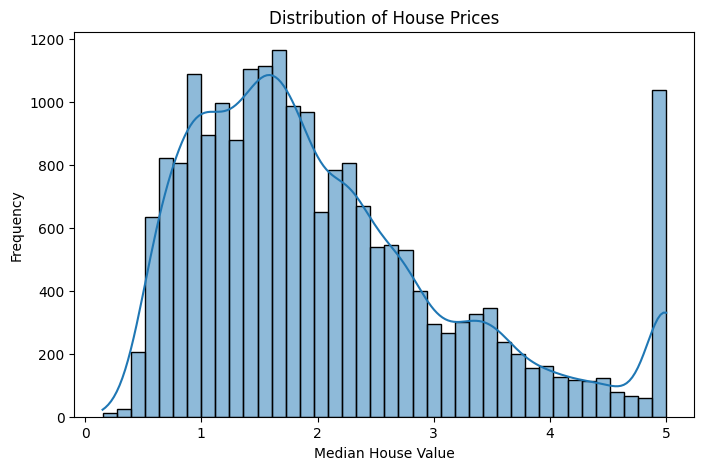

In [32]:
# Distribution of the target variable

plt.figure(figsize=(8, 5))

sns.histplot(df["MedHouseVal"], bins=40, kde=True)

plt.title("Distribution of House Prices")
plt.xlabel("Median House Value")
plt.ylabel("Frequency")

plt.savefig("../outputs/house_price_distribution.png", bbox_inches="tight")
plt.show()

### Correlation Analysis

In [14]:
# Calculate correlation matrix

correlation_matrix = df.corr()

correlation_matrix["MedHouseVal"].sort_values(ascending=False)

MedHouseVal    1.000000
MedInc         0.688075
AveRooms       0.151948
HouseAge       0.105623
AveOccup      -0.023737
Population    -0.024650
Longitude     -0.045967
AveBedrms     -0.046701
Latitude      -0.144160
Name: MedHouseVal, dtype: float64

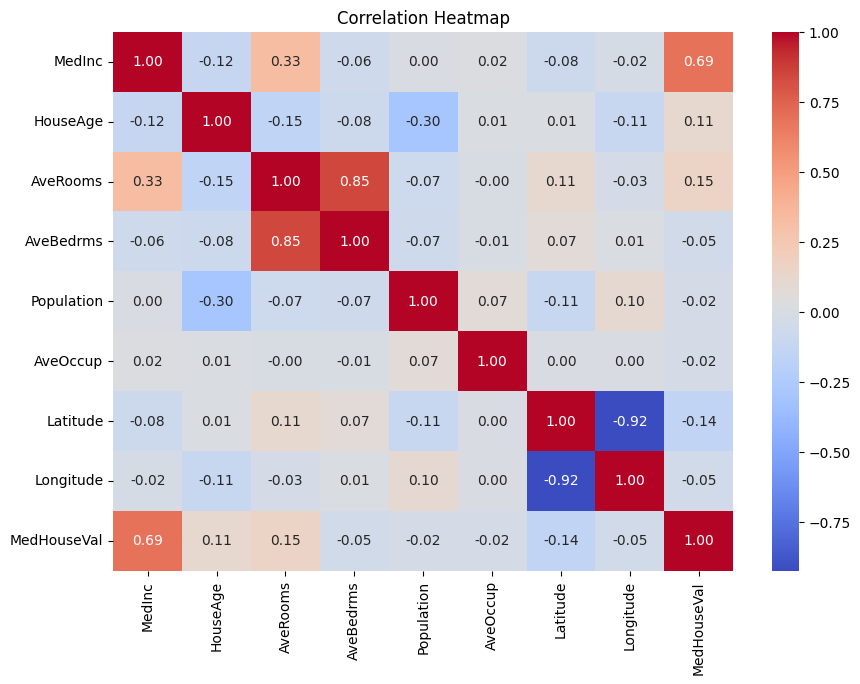

In [33]:
# Display correlation heatmap

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.savefig("../outputs/correlation_heatmap.png", bbox_inches="tight")
plt.show()

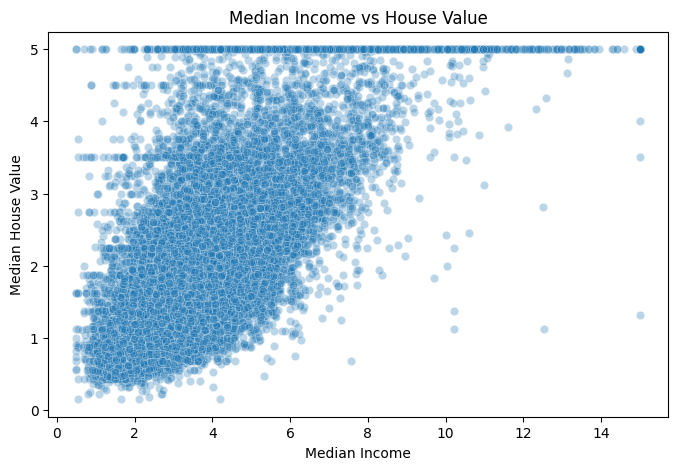

In [34]:
# Relationship between median income and house value

plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="MedInc",
    y="MedHouseVal",
    alpha=0.3
)

plt.title("Median Income vs House Value")
plt.xlabel("Median Income")
plt.ylabel("Median House Value")

plt.savefig("../outputs/income_vs_house_value.png", bbox_inches="tight")
plt.show()

## Feature Selection

The input features are separated from the target variable. The eight housing-related attributes are used as predictors, while `MedHouseVal` is selected as the target variable.

In [17]:
# Select features and target variable

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:")
print(y.name)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features:
['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

Target:
MedHouseVal

Feature shape: (20640, 8)
Target shape: (20640,)


## Train-Test Split

The dataset is divided into training and testing sets. The training data is used to train the Linear Regression model, while the testing data is used to evaluate its performance on unseen data.

In [18]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (16512, 8)
Testing data: (4128, 8)


In [19]:
test_size=0.20

In [20]:
random_state=42

## Linear Regression Model

A Linear Regression model is trained using the selected housing features to predict the median house value.

In [21]:
# Create and train the Linear Regression model

model = LinearRegression()

model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [22]:
# Make predictions on the test data

y_pred = model.predict(X_test)

print("Predictions generated successfully!")
print("First 5 predictions:")
print(y_pred[:5])

Predictions generated successfully!
First 5 predictions:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]


## Model Evaluation

The trained Linear Regression model is evaluated using Root Mean Squared Error (RMSE) and R² score.

In [23]:
# Calculate RMSE and R² score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Model Evaluation")
print("----------------")
print(f"RMSE: {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

Model Evaluation
----------------
RMSE: 0.7456
R² Score: 0.5758


### Actual vs Predicted House Values

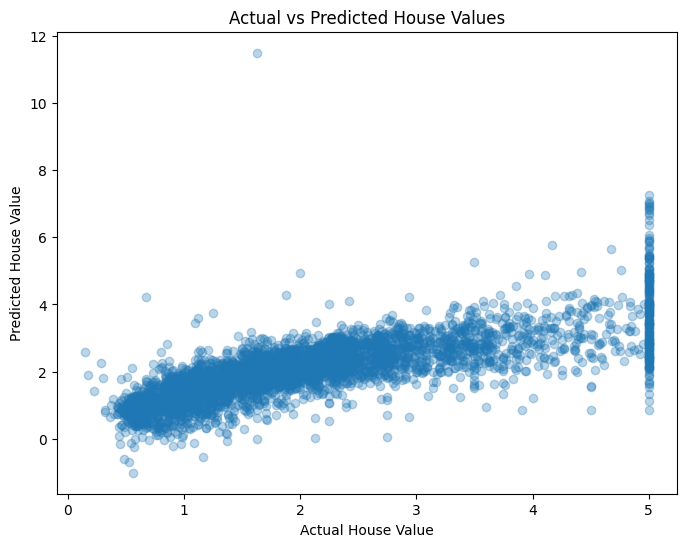

In [35]:
# Plot actual vs predicted values

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.3)

plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")
plt.title("Actual vs Predicted House Values")

plt.savefig("../outputs/actual_vs_predicted.png", bbox_inches="tight")
plt.show()

## Interpretation of Linear Regression Coefficients

The coefficients indicate how the predicted median house value changes when an individual feature increases by one unit, while keeping the other features constant.

In [25]:
# Display Linear Regression coefficients

coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients = coefficients.sort_values(
    by="Coefficient",
    ascending=False
)

coefficients

,Feature,Coefficient
3,AveBedrms,0.783145
0,MedInc,0.448675
1,HouseAge,0.009724
4,Population,-0.000002
5,AveOccup,-0.003526
2,AveRooms,-0.123323
6,Latitude,-0.419792
7,Longitude,-0.433708


### Feature Coefficients

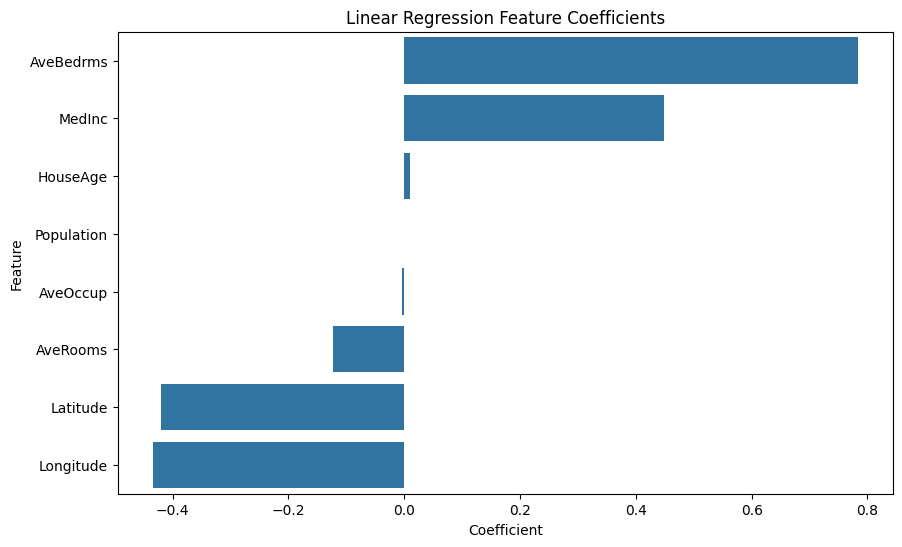

In [36]:
# Visualize feature coefficients

plt.figure(figsize=(10, 6))

sns.barplot(
    data=coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Linear Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")

plt.savefig("../outputs/feature_coefficients.png", bbox_inches="tight")
plt.show()

### Coefficient Interpretation

In [27]:
# Separate positive and negative coefficients

positive_features = coefficients[coefficients["Coefficient"] > 0]
negative_features = coefficients[coefficients["Coefficient"] < 0]

print("Positive coefficients:")
print(positive_features)

print("\nNegative coefficients:")
print(negative_features)

Positive coefficients:
     Feature  Coefficient
3  AveBedrms     0.783145
0     MedInc     0.448675
1   HouseAge     0.009724

Negative coefficients:
      Feature  Coefficient
4  Population    -0.000002
5    AveOccup    -0.003526
2    AveRooms    -0.123323
6    Latitude    -0.419792
7   Longitude    -0.433708


## Example Predictions

The trained Linear Regression model is used to predict house values for a few examples from the test dataset.

In [28]:
# Create a table of actual and predicted house values

comparison = pd.DataFrame({
    "Actual Value": y_test.values[:10],
    "Predicted Value": y_pred[:10]
})

comparison

,Actual Value,Predicted Value
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


In [29]:
# Create a table of actual and predicted house values

comparison = pd.DataFrame({
    "Actual Value": y_test.values[:10],
    "Predicted Value": y_pred[:10]
})

comparison

,Actual Value,Predicted Value
0,0.47700,0.719123
1,0.45800,1.764017
2,5.00001,2.709659
3,2.18600,2.838926
4,2.78000,2.604657
5,1.58700,2.011754
6,1.98200,2.645500
7,1.57500,2.168755
8,3.40000,2.740746
9,4.46600,3.915615


## Saving the Model

The trained Linear Regression model is saved using Joblib so that it can be reused later without retraining the model.

In [30]:
# Save the trained model

model_path = "../models/linear_regression_house_price_model.pkl"

joblib.dump(model, model_path)

print(f"Model saved successfully at: {model_path}")

Model saved successfully at: ../models/linear_regression_house_price_model.pkl


In [31]:
# Load the saved model

loaded_model = joblib.load(model_path)

# Make predictions using the loaded model

loaded_predictions = loaded_model.predict(X_test)

print("Saved model loaded successfully!")
print("First 5 predictions from saved model:")
print(loaded_predictions[:5])

Saved model loaded successfully!
First 5 predictions from saved model:
[0.71912284 1.76401657 2.70965883 2.83892593 2.60465725]
